<img src="https://i0.wp.com/amanxai.com/wp-content/uploads/2021/10/Language-Detection-with-Machine-Learning.png?resize=1024%2C576&ssl=1"/>

# 🌍 Language Detection using Machine Learning

## 📌 Project Overview
This project aims to build a machine learning model that can automatically detect the language of a given text.

We use Natural Language Processing (NLP) techniques along with a classification algorithm to train a model capable of identifying languages based on textual patterns.

## 🎯 Objectives
- Preprocess text data
- Convert text into numerical features using TF-IDF
- Train a classification model
- Evaluate performance
- Visualize results

## 🛠 Technologies Used
- Python
- Scikit-learn
- Pandas
- Matplotlib / Seaborn

In [34]:
#!pip install pandas scikit-learn deep-translator gTTS

In [3]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from deep_translator import GoogleTranslator
from gtts import gTTS
import IPython.display as ipd
import os

In [4]:
data = pd.read_csv("./Data/LangDetect.csv")
print(data.head())    

                                                Text  language
0  klement gottwaldi surnukeha palsameeriti ning ...  Estonian
1  sebes joseph pereira thomas  på eng the jesuit...   Swedish
2  ถนนเจริญกรุง อักษรโรมัน thanon charoen krung เ...      Thai
3  விசாகப்பட்டினம் தமிழ்ச்சங்கத்தை இந்துப் பத்திர...     Tamil
4  de spons behoort tot het geslacht haliclona en...     Dutch


In [5]:
data.isnull().sum()

Text        0
language    0
dtype: int64

In [6]:
data["language"].value_counts()

language
Estonian      1000
Swedish       1000
Thai          1000
Tamil         1000
Dutch         1000
Japanese      1000
Turkish       1000
Latin         1000
Urdu          1000
Indonesian    1000
Portugese     1000
French        1000
Chinese       1000
Korean        1000
Hindi         1000
Spanish       1000
Pushto        1000
Persian       1000
Romanian      1000
Russian       1000
English       1000
Arabic        1000
Name: count, dtype: int64

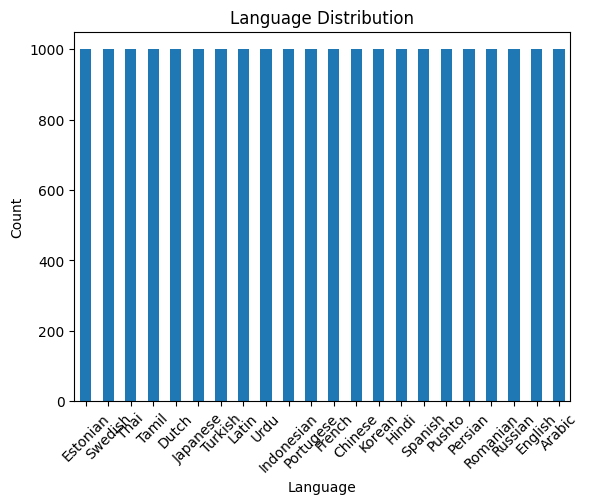

In [7]:
import matplotlib.pyplot as plt

# Language distribution
data["language"].value_counts().plot(kind="bar")
plt.title("Language Distribution")
plt.xlabel("Language")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [8]:
# Vektörleştirme ve Eğitim
cv = CountVectorizer()
X = cv.fit_transform(data["Text"])
y = data["language"]

model = MultinomialNB()
model.fit(X, y)

print("Model başarıyla eğitildi!")

Model başarıyla eğitildi!


In [40]:
def dil_asistani():
    # 1. Giriş Al
    user_text = input("Analiz edilecek metni girin: ")
    if not user_text: return
    
    # 2. ML Modeli ile Dil Tespiti
    vect_text = cv.transform([user_text]).toarray()
    prediction = model.predict(vect_text)[0]
    print(f"\n[ML Tahmini]: {prediction}")
    
    # 3. Çeviri Seçenekleri
    print("\nHangi dile çevrilsin? (1: Türkçe, 2: İngilizce, 3: Almanca)")
    secim = input("Seçiminiz (1/2/3): ")
    
    hedef_diller = {"1": "tr", "2": "en", "3": "de"}
    hedef = hedef_diller.get(secim, "tr")
    
    # 4. Çeviri ve Seslendirme
    try:
        translated = GoogleTranslator(source='auto', target=hedef).translate(user_text)
        print(f"[Çeviri]: {translated}")
        
        # Ses dosyası oluşturma
        tts = gTTS(text=translated, lang=hedef)
        tts.save("sonuc.mp3")
        
        # Notebook içinde ses oynatıcıyı göster
        return ipd.Audio("sonuc.mp3", autoplay=True)
    except Exception as e:
        print(f"Hata oluştu: {e}")


In [41]:
dil_asistani()

Analiz edilecek metni girin:  merhabalar, iyi akşamlar



[ML Tahmini]: Turkish

Hangi dile çevrilsin? (1: Türkçe, 2: İngilizce, 3: Almanca)


Seçiminiz (1/2/3):  2


[Çeviri]: hello, good evening


## 📈 Conclusion

In this project, we successfully built a machine learning model to detect languages from text data.

### ✅ Key Results:
- The model achieved high accuracy on test data
- TF-IDF proved effective for text representation
- Naive Bayes performed well for classification

### 🚀 Future Improvements:
- Use deep learning models (LSTM, Transformers)
- Increase dataset size
- Handle mixed-language text

This system can be used in real-world applications such as:
- Chat applications
- Content filtering
- Translation systems